# Time Series Analysis

## Libraries used

In [4]:
# imports
!pip install wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
from collections import Counter

# Reproducibility
RANDOM_STATE = 10
np.random.seed(RANDOM_STATE)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 60.2 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.


## Task 1: Data Loading & Exploration (Víctor)

In [5]:
# display options
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', context='notebook')

# the 14 records selected by the assignment
RECORDS = ['100', '101', '105', '106', '108', '109', '111',
           '112', '115', '117', '119', '201', '213', '219']
# 3-class scheme
LABEL_MAP = {
    # N — Normal / bundle branch
    'N': 'N', '.': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    # S — Supraventricular ectopic
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    # V — Ventricular ectopic
    'V': 'V', 'E': 'V',
}

# colours for each class
CLASS_COLORS = {'N': '#2ca02c', 'S': '#1f77b4', 'V': '#d62728'}

In [6]:
# load the 14 records
records_data = {}
for rid in RECORDS:
    rec = wfdb.rdrecord(rid, pn_dir='mitdb')
    ann = wfdb.rdann(rid, 'atr', pn_dir='mitdb')
    records_data[rid] = {
        'signal':  rec.p_signal[:, 0],
        'fs':      rec.fs,
        'samples': np.asarray(ann.sample),
        'symbols': np.asarray(ann.symbol),
    }

FS = records_data['100']['fs']
n_total_annotations = sum(d['samples'].size for d in records_data.values())

print(f'Records loaded         : {len(records_data)}')
print(f'Sampling rate          : {FS} Hz')
print(f'Signal shape (record 100): {records_data["100"]["signal"].shape}')
print(f'Total raw annotations  : {n_total_annotations:,}')

Records loaded         : 14
Sampling rate          : 360 Hz
Signal shape (record 100): (650000,)
Total raw annotations  : 31,219


The 14 records were loaded without any problem at 360Hz, with 30 minutes of every signal (650000 samples = 30min x 60s x 360Hz). We have 31.219 raw annotations before applying AAMI.

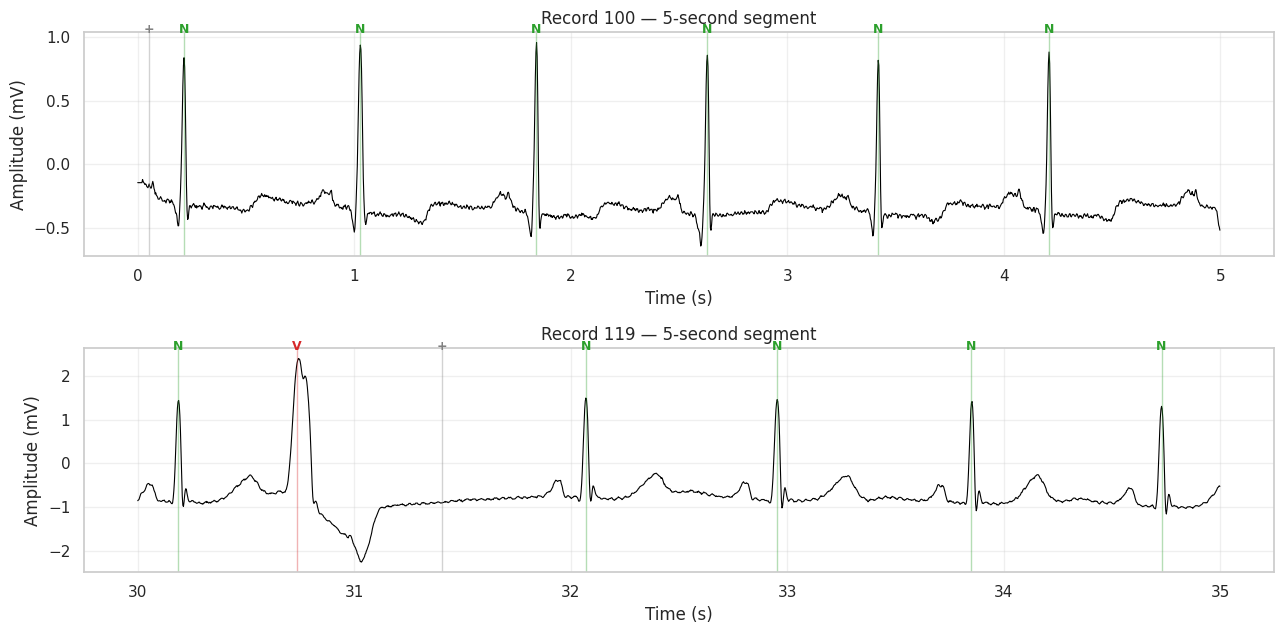

In [11]:
# ECG signals plots
def plot_ecg_segment(record_id, start_seconds, duration_seconds, ax):
    d = records_data[record_id]
    fs = d['fs']
    start = int(start_seconds * fs)
    end   = int((start_seconds + duration_seconds) * fs)
    signal = d['signal'][start:end]
    t = np.arange(start, end) / fs

    ax.plot(t, signal, color='black', lw=0.8)

    in_seg = (d['samples'] >= start) & (d['samples'] < end)
    for s, sym in zip(d['samples'][in_seg], d['symbols'][in_seg]):
        aami = LABEL_MAP.get(sym, '?')
        color = CLASS_COLORS.get(aami, 'gray')
        ax.axvline(s / fs, color=color, alpha=0.35, lw=1)
        ax.text(s / fs, signal.max() * 1.05, sym, color=color,
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude (mV)')
    ax.set_title(f'Record {record_id} — {duration_seconds}-second segment')
    ax.grid(alpha=0.3)

fig, axes = plt.subplots(2, 1, figsize=(13, 6.5))
plot_ecg_segment('100', start_seconds=0,  duration_seconds=5, ax=axes[0])
plot_ecg_segment('119', start_seconds=30, duration_seconds=5, ax=axes[1])
plt.tight_layout()
plt.show()

Record 100 shows regular sinus rhythm (six N beats evenly spaced at ~0.8 s with consistent narrow-QRS morphology).

Record 119 highlights the contrast the classifier must learn: a single V beat (red) appears between normal beats, with markedly wider QRS, nearly double the amplitude and a clearly distinct shape.

The grey + markers correspond to rhythm-change annotations, which are not part of the AAMI scheme and will be discarded in the next step.

Total annotations : 31,219
Kept (N/S/V)      : 30,162
Discarded         : 1,057

Discarded symbols (top 10):
symbol
F    369
+    252
~    196
x    181
|     48
Q      7
"      4
      count  proportion
aami                   
N     28412      0.9420
S       206      0.0068
V      1544      0.0512


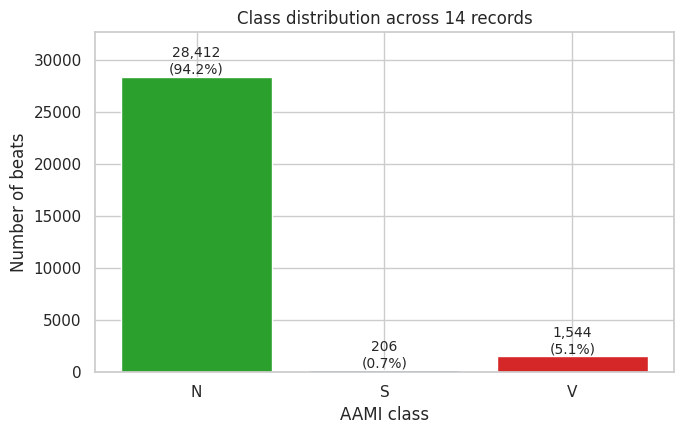

In [8]:
# AAMI label mapping and class distribution
rows = []
for rid, d in records_data.items():
    for s, sym in zip(d['samples'], d['symbols']):
        rows.append({'record_id': rid, 'sample': s, 'symbol': sym,
                     'aami': LABEL_MAP.get(sym, None)})

annotations_df = pd.DataFrame(rows)
beats_df = annotations_df.dropna(subset=['aami']).reset_index(drop=True)

n_kept     = len(beats_df)
n_discard  = len(annotations_df) - n_kept

print(f'Total annotations : {len(annotations_df):,}')
print(f'Kept (N/S/V)      : {n_kept:,}')
print(f'Discarded         : {n_discard:,}')
print('\nDiscarded symbols (top 10):')
print(annotations_df[annotations_df['aami'].isna()]['symbol']
      .value_counts().head(10).to_string())

class_counts = beats_df['aami'].value_counts().reindex(['N', 'S', 'V'])
class_props  = beats_df['aami'].value_counts(normalize=True).reindex(['N', 'S', 'V'])

balance = pd.DataFrame({'count': class_counts, 'proportion': class_props.round(4)})
print(balance)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(class_counts.index, class_counts.values,
              color=[CLASS_COLORS[c] for c in class_counts.index])
for b, v in zip(bars, class_counts.values):
    ax.text(b.get_x() + b.get_width()/2, v,
            f'{v:,}\n({v/class_counts.sum()*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Number of beats')
ax.set_xlabel('AAMI class')
ax.set_title('Class distribution across 14 records')
ax.set_ylim(0, class_counts.max() * 1.15)
plt.tight_layout()
plt.show()

After applying the AAMI mapping, 30,162 beats are retained (96.6% of the 31,219 raw annotations) and 1,057 are discarded — mostly fusion beats (F, n=369), rhythm-change markers (52) and noise annotations (196).
The class distribution is severely imbalanced: 94.2% N, 5.1% V and only 0.7% (just 206 beats across all 14 records). This confirms that macro F1 is the only sensible headline metric.

In [12]:
#heatmap(need features) will be executed at the end of task 2

def plot_feature_correlation(features_df):
    available = [c for c in FEATURE_NAMES if c in features_df.columns]
    corr = features_df[available].corr()

    fig, ax = plt.subplots(figsize=(8, 6.5))
    sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1,
                annot=True, fmt='.2f', square=True, linewidths=0.4,
                cbar_kws={'shrink': 0.75}, ax=ax)
    ax.set_title('Pearson correlation — 8 engineered features')
    plt.tight_layout()
    plt.show()

    # Top correlated pairs
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    pairs = (corr.where(mask).stack()
                 .rename('corr').reset_index()
                 .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2'}))
    pairs['abs_corr'] = pairs['corr'].abs()
    top = pairs.sort_values('abs_corr', ascending=False).head(5).reset_index(drop=True)
    print('Top 5 correlated feature pairs:')
    print(top.round(3).to_string(index=False))

## Task 2: Preprocessing & Feature Analysis (---name of the owner---)

In [ ]:
FEATURE_NAMES = ['RR_current', 'RR_prev', 'RR_ratio', 'RR_local_mean', 'R_amplitude', 'QRS_duration', 'QRS_energy', 'ST_mean']

In [ ]:
#heatmap (task 1)
plot_feature_correlation(features_df)

## Task 3: RNN - Sequence Classification (---name of the owner---)

### Task 3.5: Extension - LSTM (---name of the owner---)

## Task 4: Model Comparison & Evaluation (---name of the owner---)